# Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [ ]:
def load_dataset(filepath, sheet_name=0):
    if filepath.endswith('.csv'):
        return pd.read_csv(filepath)
    return pd.read_excel(filepath, sheet_name=sheet_name)

# Inspect Dataset

In [22]:
def inspect_dataset(df):
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Data Types:\n{df.dtypes}")
    print(f"Missing Values:\n{df.isnull().sum()}")
    print(f"Memory Usage (MB): {round(df.memory_usage(deep=True).sum() / 1024**2, 2)}")
    display(df.head())

# Handling missing values 
based on a column-mapping dictionary

In [23]:
def handle_missing_values(df, impute_dict=None):
    df_clean = df.copy()
    cols_to_drop = [c for c in ['Unnamed: 0', 'Row ID'] if c in df_clean.columns]
    if cols_to_drop:
        df_clean = df_clean.drop(columns=cols_to_drop)
    if impute_dict:
        for col, val in impute_dict.items():
            if col in df_clean.columns:
                df_clean[col] = df_clean[col].fillna(val)
    return df_clean

# Handling outliers

In [24]:
def handle_outliers_iqr(df, columns, factor=1.5, method='cap'):
    df_clean = df.copy()
    
    for col in columns:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - (factor * IQR)
            upper_bound = Q3 + (factor * IQR)
            
            if method == 'cap':
                df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
            elif method == 'remove':
                # Filtering out rows outside boundaries
                df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
                
    return df_clean

# Feature engineering
1. converting date columns to datetime 
2. calculating shipping duration ,profit margin ratio
3. Extracting individual time parts from the full order date timestamp
4. Splitting continuous sales numbers into 3 equal-volume categorical

In [25]:
def engineer_features(df, start_date_col, end_date_col, sales_col, profit_col):
    df_feat = df.copy()
    
    # Date Conversions
    df_feat[start_date_col] = pd.to_datetime(df_feat[start_date_col])
    df_feat[end_date_col] = pd.to_datetime(df_feat[end_date_col])
    
    # Feature Engineering
    df_feat["Shipping Duration"] = (df_feat[end_date_col] - df_feat[start_date_col]).dt.days
    df_feat["Profit Margin"] = (df_feat[profit_col] / df_feat[sales_col]).replace([np.inf, -np.inf], np.nan).fillna(0)
    df_feat["Order Month"] = df_feat[start_date_col].dt.month
    df_feat["Order Year"] = df_feat[start_date_col].dt.year
    df_feat["YearMonth"] = df_feat[start_date_col].dt.to_period("M")
    
    # Binned Sales Performance Tiers
    q33, q66 = df_feat[sales_col].quantile(0.33), df_feat[sales_col].quantile(0.66)
    df_feat["Sales Category"] = pd.cut(df_feat[sales_col], bins=[-np.inf, q33, q66, np.inf], labels=["Low", "Medium", "High"])
    
    return df_feat

# Optimize Memory

In [26]:
def optimize_memory(df, categorical_cols):
    df_opt = df.copy()
    
    # Convert string categories to category dtype
    for col in categorical_cols:
        if col in df_opt.columns:
            df_opt[col] = df_opt[col].astype("category")
            
    # Downcast numerics
    for col in df_opt.select_dtypes(include=['float64']).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast='float')
    for col in df_opt.select_dtypes(include=['int64']).columns:
        df_opt[col] = pd.to_numeric(df_opt[col], downcast='integer')
        
    return df_opt

# KPI summary

In [27]:
def build_kpi_summary(df, sales_col, profit_col, order_id_col, qty_col, duration_col):
    return pd.DataFrame({
        "Metric": ["Total Revenue", "Total Profit", "Overall Profit Margin", "Total Orders", "Units Sold", "Avg Shipping Time"],
        "Value": [
            f"${df[sales_col].sum():,.2f}",
            f"${df[profit_col].sum():,.2f}",
            f"{(df[profit_col].sum() / df[sales_col].sum()) * 100:.2f}%",
            f"{df[order_id_col].nunique():,}",
            f"{df[qty_col].sum():,}",
            f"{df[duration_col].mean():.1f} Days"
        ]
    })

# Data Pipeline Execution

In [28]:
file_path = r'D:\DEPI\Sample - Superstore 2019.xls'
sheet_name = "Orders"

df_raw = load_dataset(file_path, sheet_name=sheet_name)

inspect_dataset(df_raw)

df_filled = handle_missing_values(df_raw, impute_dict={"Postal Code": 5401})

df_no_outliers = handle_outliers_iqr(df_filled, columns=["Sales", "Profit"], method='cap')
df_engineered = engineer_features(
    df_no_outliers, 
    start_date_col="Order Date", 
    end_date_col="Ship Date", 
    sales_col="Sales", 
    profit_col="Profit"
)

df = optimize_memory(
    df_engineered, 
    categorical_cols=["Ship Mode", "Segment", "Region", "Category", "Sub-Category", "Sales Category"]
)

print(f"Final Shape: {df.shape} | Memory: {df.memory_usage().sum() / 1024**2:.2f} MB")

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Data Types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code              float64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
d

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Final Shape: (9994, 26) | Memory: 1.18 MB


# Summary Statistics & Executive KPIs

In [29]:
num_cols = ["Sales", "Profit", "Quantity", "Discount", "Shipping Duration", "Profit Margin"]

print("Summary Statistics for Numeric Columns:")
display(df[num_cols].describe().round(2))

# KPIs
kpis = build_kpi_summary(df, "Sales", "Profit", "Order ID", "Quantity", "Shipping Duration")
display(kpis)

Summary Statistics for Numeric Columns:


,Sales,Profit,Quantity,Discount,Shipping Duration,Profit Margin
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,140.28,16.07,3.79,0.16,3.96,0.13
std,168.80,29.49,2.23,0.21,1.75,0.40
min,0.44,-39.72,1.00,0.00,0.00,-2.75
25%,17.28,1.73,2.00,0.00,3.00,0.08
50%,54.49,8.67,3.00,0.20,4.00,0.25
75%,209.94,29.36,5.00,0.20,5.00,0.35
max,498.93,70.82,14.00,0.80,7.00,0.50


,Metric,Value
0,Total Revenue,"$1,401,969.38"
1,Total Profit,"$160,583.72"
2,Overall Profit Margin,11.45%
3,Total Orders,"5,009"
4,Units Sold,"37,873"
5,Avg Shipping Time,4.0 Days


# Q1: What are the primary metrics correlated with Profit and Sales?

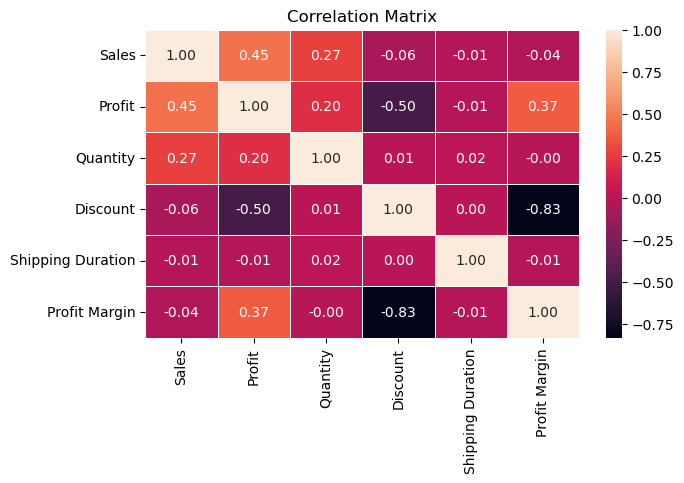

In [30]:
plt.figure(figsize=(7, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="rocket", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

**Key Insights :**

* positive relation between *discount* and *profit* as it's **0.50** but it's not too high so it means discounts not the only factor to increase profit but there is other factors such as sales

* also, we notice that *discount* has negative correlation with *profit margin* **(-0.83 )** 

# Q2: What is the monthly sales revenue trend over time?

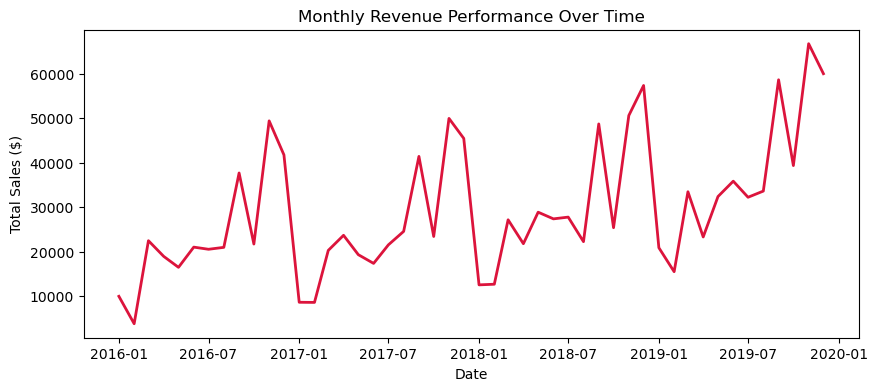

In [31]:
plt.figure(figsize=(10, 4))
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].dt.to_timestamp()
sns.lineplot(data=monthly_sales, x="YearMonth", y="Sales", color="crimson", linewidth=2)
plt.title("Monthly Revenue Performance Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.show()

**Key Insights:**
* **Positive Multi-Year Growth:** Revenue shows a strong overall upward from 2016 to 2019, peaking at ~$120K in late 2019.
* **Predictable Seasonality:** Sales surge dramatically every year in Q4 (Sept–Nov) due to holiday demand and annual spending cycles.
* **Q1 Inventory & Cash-Flow Risk:** January/February experience steep seasonal dips every year. Supply chain and marketing budgets should be scaled down in early Q1 and scaled up starting in Q3.

# Q3: Which Product Categories generate the highest revenue and profit?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\2637897536.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_perf = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index().melt(id_vars="Category")


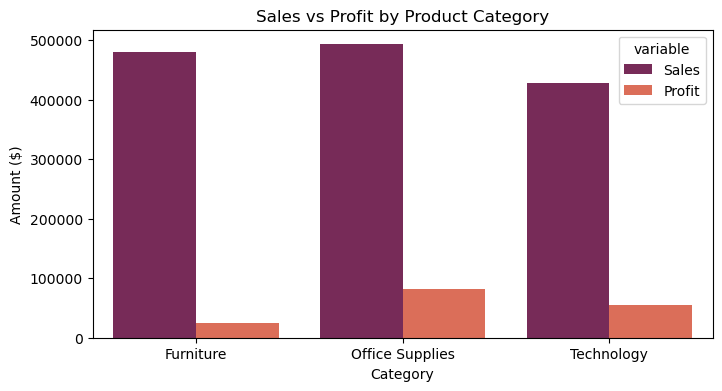

In [32]:
plt.figure(figsize=(8, 4))
cat_perf = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index().melt(id_vars="Category")
sns.barplot(data=cat_perf, x="Category", y="value", hue="variable", palette="rocket")
plt.title("Sales vs Profit by Product Category")
plt.ylabel("Amount ($)")
plt.show()

**Key Insights:**
* office supplies has the highest sales also the highest profit

# Q4: How is profitability distributed across Customer Segments?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\1892833263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Segment", y="Profit", palette="rocket")


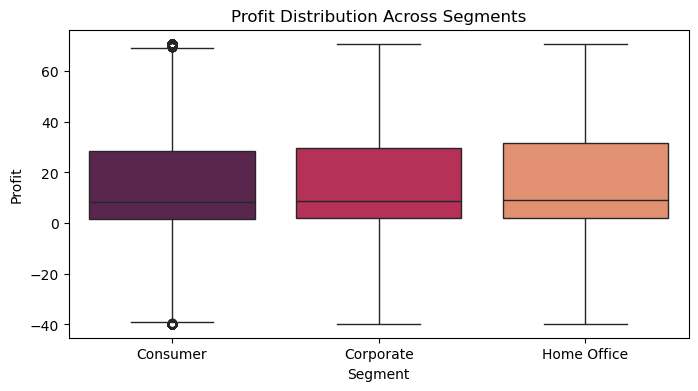

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Segment", y="Profit", palette="rocket")
plt.title("Profit Distribution Across Segments")
plt.show()

**Key Insights:**
* **Uniform Median Profit:** Profit distribution per order is nearly identical across Consumer, Corporate, and Home Office segments, indicating consistent baseline pricing and demand patterns
* **Loss Risk is Customer-Agnostic:** Negative profit orders drop down to -$40 across all three segments, proving that profitability issues stem from discounting rules or product margins rather than specific customer groups

# Q5: How does Shipping Duration vary by Ship Mode?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\670083360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Ship Mode", y="Shipping Duration", palette="rocket", errorbar=None)


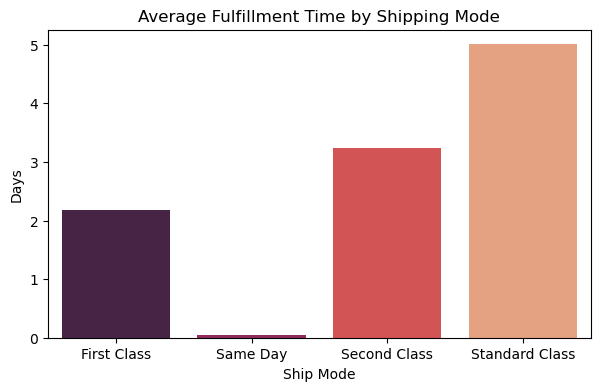

In [34]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="Ship Mode", y="Shipping Duration", palette="rocket", errorbar=None)
plt.title("Average Fulfillment Time by Shipping Mode")
plt.ylabel("Days")
plt.show()

**Key Insights:**
* **Fastest Shipping Tier:** Same Day shipping has the lowest average fulfillment time, taking close to 0 days

* **Slowest Shipping Tier:** Standard Class takes the longest to fulfill, averaging 5 days

# Q6: How are order volumes distributed across low, medium, and high sales tiers?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\3100753685.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sales Category", palette="rocket")


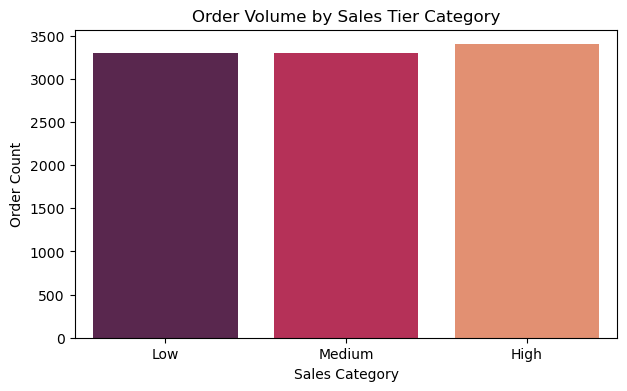

In [35]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Sales Category", palette="rocket")
plt.title("Order Volume by Sales Tier Category")
plt.ylabel("Order Count")
plt.show()

**Key Insights:**
* almost Uniform Volume distribution

# Q7: What is the impact of Discount rates on Profitability?

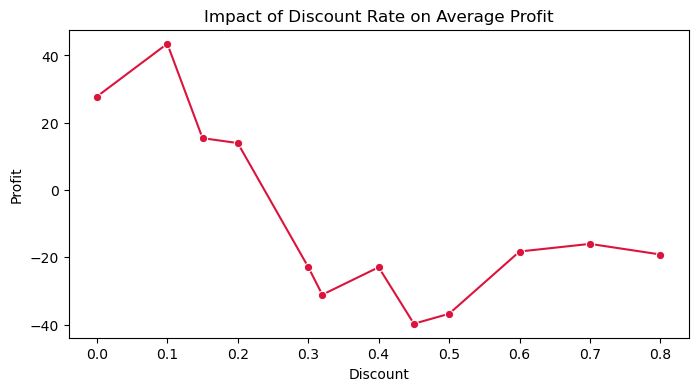

In [36]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x="Discount", y="Profit", color="crimson", errorbar=None, marker="o")
plt.title("Impact of Discount Rate on Average Profit")
plt.show()

**Key Insights:**
* Profitability peaks at a 10% discount rate. Discounts under 20% maintain positive profitability
* Any discount exceeding 20% pushes average order profit into negative territory
* **Actionable Policy Recommendation:** Immediately cap promotional discount authority at 20%. Any discount above 20% requires managerial approval to prevent heavy profit destruction.

# Q8: Which top 10 States drive the majority of sales revenue?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\2837623574.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x="Sales", y="State", palette="rocket")


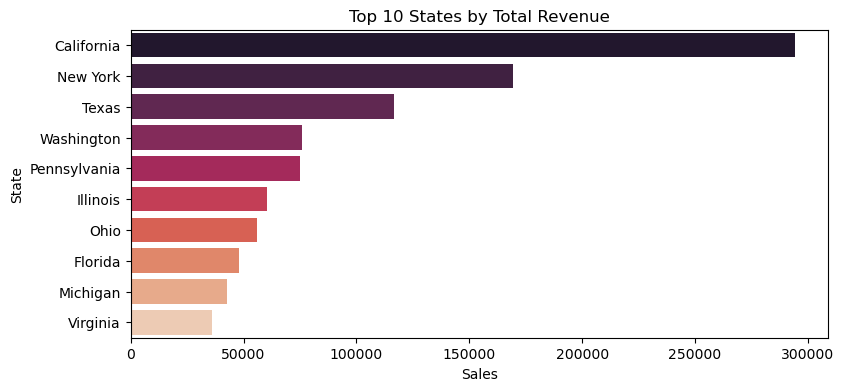

In [37]:
plt.figure(figsize=(9, 4))
top_states = df.groupby("State")["Sales"].sum().nlargest(10).reset_index()
sns.barplot(data=top_states, x="Sales", y="State", palette="rocket")
plt.title("Top 10 States by Total Revenue")
plt.show()

**Key Insights :**
* california has the highst state with total revenue more than 250k
* new work the second highst state with total revenue more than 150k
* the other states their total revenue don't exceed 150k 
* so there should be more focus on califonia and new york

# Q9: Which Sub-Categories generate the lowest profit (or highest losses)?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\2689541743.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values().reset_index()
C:\Users\Active\AppData\Local\Temp\ipykernel_7308\2689541743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_profit, x="Profit", y="Sub-Category", palette="rocket")


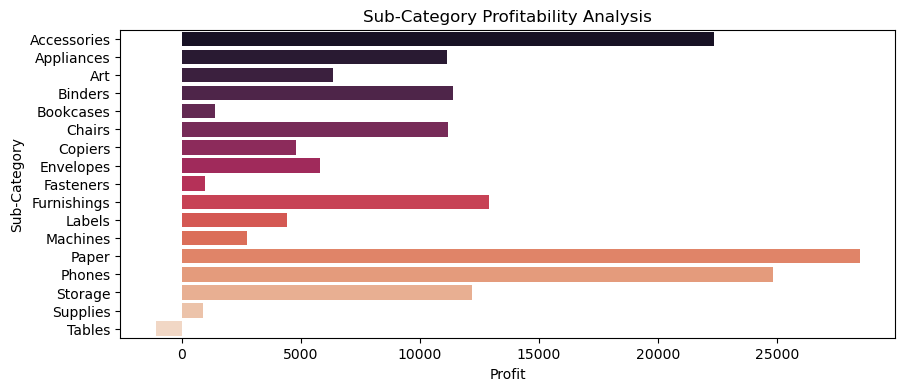

In [38]:
plt.figure(figsize=(10, 4))
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values().reset_index()
sns.barplot(data=subcat_profit, x="Profit", y="Sub-Category", palette="rocket")
plt.title("Sub-Category Profitability Analysis")
plt.show()

**Key Insights :**
* papers, accessories and phones have the highest profit
* tables cause loss in the profit

# Q10: What is the average Profit Margin percentage by Regional Market?

C:\Users\Active\AppData\Local\Temp\ipykernel_7308\3470914623.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_margin = df.groupby("Region")["Profit Margin"].mean().reset_index()
C:\Users\Active\AppData\Local\Temp\ipykernel_7308\3470914623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_margin, x="Region", y="Profit Margin", palette="rocket")


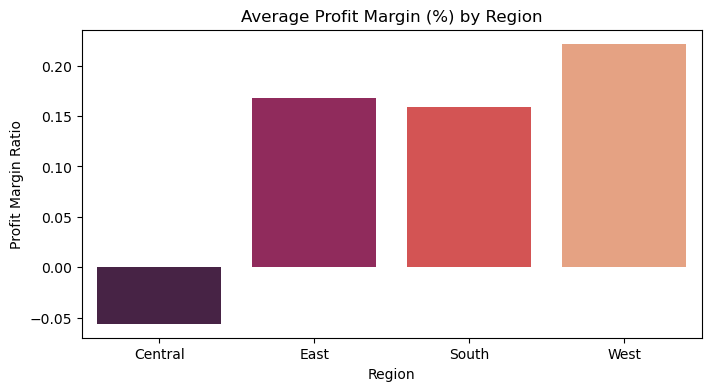

In [39]:
plt.figure(figsize=(8, 4))
region_margin = df.groupby("Region")["Profit Margin"].mean().reset_index()
sns.barplot(data=region_margin, x="Region", y="Profit Margin", palette="rocket")
plt.title("Average Profit Margin (%) by Region")
plt.ylabel("Profit Margin Ratio")
plt.show()

**Key Insights:**
* **West Region Tops Profitability:** The West region is the company's most efficient market
* **Stable Performers:** East and South regions demonstrate consistent profit margins
* **Urgent Intervention Needed in Central Region :** The Central region is losing money overall on average transactions